<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Conversores AD e DA</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 02 de fevereiro de 2026
</div>

<div style="page-break-after: always;"></div>

<a id="1-introdução"></a>
# 1. Introdução

O avanço das tecnologias digitais e das comunicações tem impulsionado a necessidade de compreender, de forma cada vez mais detalhada, os processos de conversão entre sinais analógicos e digitais. Nesse contexto, os conversores analógico-digitais (ADC) e digital-analógicos (DAC) desempenham papel fundamental, pois estabelecem a interface entre o mundo físico contínuo e os sistemas computacionais discretos. A correta modelagem e análise desses dispositivos permitem avaliar os impactos de suas limitações práticas.

Este relatório tem como objetivo apresentar uma abordagem inicial para a implementação e simulação de ADCs e DACs em ambiente computacional, utilizando a linguagem Python. A proposta consiste em desenvolver modelos que representem tanto o funcionamento ideal desses dispositivos quanto suas imperfeições reais, possibilitando o estudo dos efeitos causados em sinais de diferentes naturezas. A partir dessa modelagem, busca-se compreender como parâmetros como resolução, taxa de amostragem e filtros de reconstrução influenciam diretamente métricas demétricas de desempenho, incluindo a taxa de erro de bits (BER) em sistemas de comunicação.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

plt.style.use('seaborn-v0_8')

In [27]:
def adc(x_t, fs, f_orig, res, adc_min = 0, adc_max = 0):
    """
    Function that samples, quantizes, and map into symbols a signal x_t

    Parameters:
        x_t: array_like
            Input analog signal
        fs: float
            Sampling frequency of the adc. Must be much smaller than f_orig [Hz]
        f_orig: float
            Sampling frequency of the input signal x_t. Much be much higher than fs [Hz]
        res: int
            Resolution of the adc [bits]
        adc_min: float
            Minimal value read by the adc. If not given, adc_min = min(x_t)
        adc_max: float
            Maximal value read by hte adc. If not given, adc_max = max(x_t)
    """

    if adc_min == 0: adc_min = np.min(x_t)
    if adc_max == 0: adc_max = np.max(x_t)

    interval = (adc_max-adc_min)/2**res
    k = round(f_orig/fs)

    discrete_x = x_t[::k]
    quantized_x = np.zeros_like(discrete_x)

    digital_x = []

    for j in range(len(discrete_x)):
        level = int((discrete_x[j]-adc_min) / interval)
        if level >= 2**res: level = 2**res - 1
        quantized_x[j] = adc_min + level*interval + interval/2
        symbol = level ^ (level >> 1) 
        digital_x.append(list(map(int, bin(symbol)[2:].zfill(res))))
    return quantized_x, digital_x

[[1, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 1, 0, 0], [1, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 0, 1, 0, 0], [1, 0, 0, 0, 0, 1, 0, 1], [1, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 1, 0, 1], [1, 0, 0, 1, 0, 1, 0, 0], [1, 0, 1, 0, 1, 1, 1, 0], [1, 1, 1, 1, 0, 1, 0, 0], [1, 1, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 0, 1, 0, 0], [0, 0, 1, 0, 1, 1, 1, 0], [0, 0, 0, 1, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0, 1], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 1], [0, 0, 0, 1, 0, 1, 0, 0], [0, 0, 1, 0, 1, 1, 1, 0], [0, 1, 1, 1, 0, 1, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 1, 0, 0], [1, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 0, 1, 0, 0], [1, 0, 0, 0, 0, 1, 0, 1], [1, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 1, 0, 1], [1, 0, 0, 1, 0, 1, 0, 0], [1, 0, 1, 0, 1, 1, 1, 0], [1, 1, 1, 1, 0, 1, 0, 0], [1, 1, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 0, 1, 0, 0], [0, 0, 1, 0, 1, 1, 1, 0], [0, 0, 0, 1, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0, 1], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 1], [0, 0, 0, 1, 0, 1, 0, 0], [0, 0, 1, 0

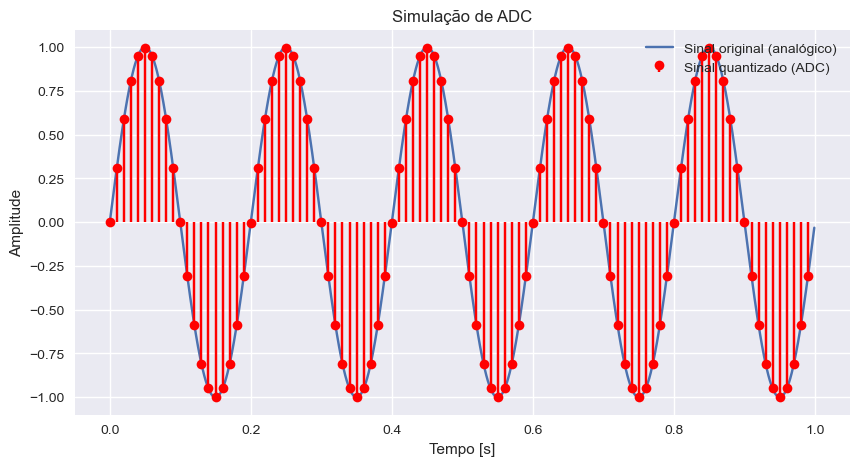

In [28]:
f_signal = 5 # frequência do sinal [Hz] 
f_orig = 1000 # frequência de amostragem original [Hz] 
t = np.linspace(0, 1, f_orig, endpoint=False) 
x_t = np.sin(2*np.pi*f_signal*t) # sinal senoidal 

# --- Aplicar ADC --- #
fs = 100 # frequência de amostragem do ADC [Hz] 
res = 8 # resolução em bits 

quantized_x, digital_x = adc(x_t, fs, f_orig, res, -1, 1)
print(digital_x) 

# --- Plotar --- 
plt.figure(figsize=(10,5)) 
plt.plot(t, x_t, label="Sinal original (analógico)")
plt.stem(np.linspace(0,1,len(quantized_x),endpoint=False), quantized_x, linefmt='r-', markerfmt='ro', basefmt=' ', label="Sinal quantizado (ADC)") 
plt.xlabel("Tempo [s]") 
plt.ylabel("Amplitude") 
plt.title("Simulação de ADC") 
plt.legend(loc = "upper right") 
plt.grid(True) 
plt.show()